In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# Load dataset
df = pd.read_csv('dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df = df[['Date', 'Adj Close']]
df = df.dropna()
df.set_index('Date', inplace=True)

# Normalisasi
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Sliding window
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 50
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split data
split_idx = int(0.7 * len(X))
X_train, X_temp = X[:split_idx], X[split_idx:]
y_train, y_temp = y[:split_idx], y[split_idx:]
X_val, X_test = np.split(X_temp, 2)
y_val, y_test = np.split(y_temp, 2)

c:\Users\yunan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 2.8517 - mae: 1.1758 - val_loss: 0.2592 - val_mae: 0.5082 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5172 - mae: 0.5439 - val_loss: 0.4744 - val_mae: 0.6883 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2585 - mae: 0.3810 - val_loss: 0.1321 - val_mae: 0.3627 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1522 - mae: 0.2834 - val_loss: 0.0128 - val_mae: 0.1110 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0744 - mae: 0.2039 - val_loss: 0.0013 - val_mae: 0.0315 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0462 - mae: 0.1573 - val_loss: 0.0013 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0381 - mae: 0.1415 - val_loss: 5.2220e-04 - val_mae: 0.0177 - learning_rate: 0.0010
Epoch 8/

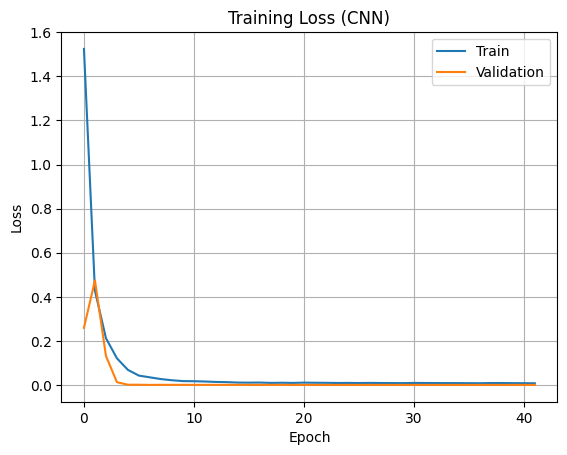

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training MAE: 122.80, RMSE: 179.27
Testing  MAE: 110.06, RMSE: 171.52


In [10]:
# Build CNN model
def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

model = build_cnn_model((X_train.shape[1], X_train.shape[2]))

# Callbacks
callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ModelCheckpoint('best_cnn_model.keras', save_best_only=True),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
]

# Training
history = model.fit(X_train, y_train, epochs=200, batch_size=32,
                    validation_data=(X_val, y_val), callbacks=callbacks)

# Plot training history
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training Loss (CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Prediction
train_pred = model.predict(X_train).flatten()
test_pred = model.predict(X_test).flatten()

# Denormalisasi
def inverse_transform(preds):
    dummy = np.zeros((len(preds), scaled_data.shape[1]))
    dummy[:, 0] = preds
    return scaler.inverse_transform(dummy)[:, 0]

y_train_inv = inverse_transform(y_train)
train_pred_inv = inverse_transform(train_pred)
y_test_inv = inverse_transform(y_test)
test_pred_inv = inverse_transform(test_pred)

# Evaluation
train_mae = mean_absolute_error(y_train_inv, train_pred_inv)
test_mae = mean_absolute_error(y_test_inv, test_pred_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))

print(f'Training MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}')
print(f'Testing  MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}')

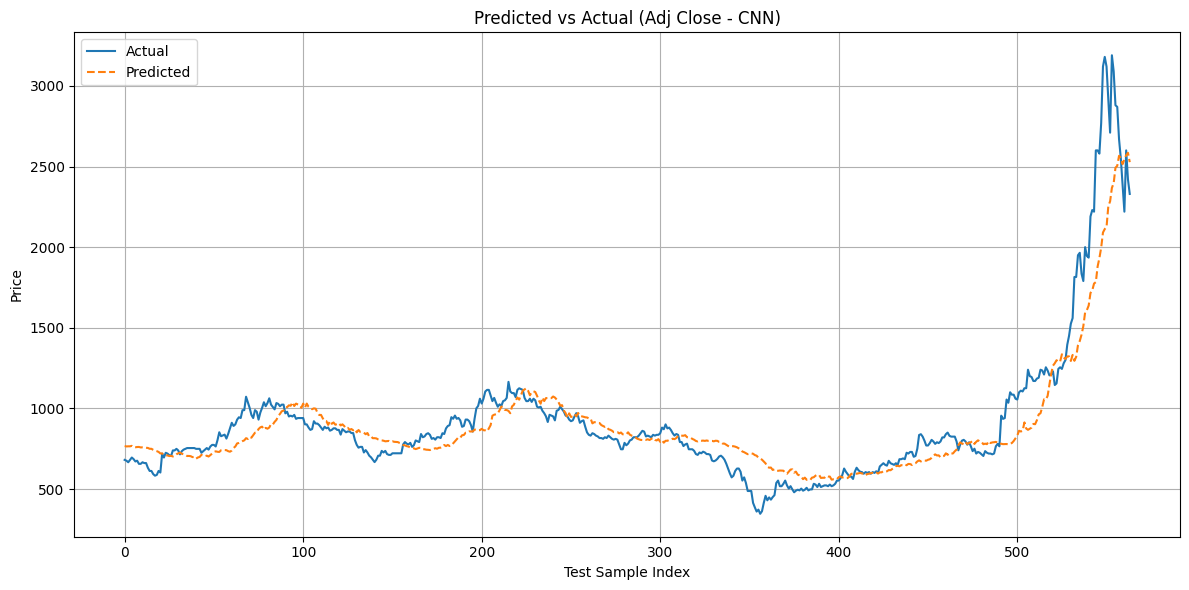

In [11]:
# Plot prediction vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(test_pred_inv, '--', label='Predicted')
plt.title('Predicted vs Actual (Adj Close - CNN)')
plt.xlabel('Test Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
